# **Gabriel Lamoglia (MediaPipe + MLP)**

In [1]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

/Users/lucatvillela/Documents/facul/venvFacul/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
DATASET_PATH = "aumentado"
EPOCHS = 30
BATCH_SIZE = 16

In [3]:
def extract_landmarks(path):
    """
    Simula a etapa de pré-processamento do trabalho de Lamoglia.
    Em vez de alimentar imagens na rede, alimentamos vetores de coordenadas.
    """
    mp_hands = mp.solutions.hands
    data_features = []
    data_labels = []
    classes = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    
    print("[Gabriel] Iniciando extração de esqueleto com MediaPipe (pode demorar)...")
    
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands:
        for idx, cls in enumerate(classes):
            cls_dir = os.path.join(path, cls)
            print(f"Processando classe: {cls}")
            for img_name in os.listdir(cls_dir):
                img_path = os.path.join(cls_dir, img_name)
                img = cv2.imread(img_path)
                if img is None: continue
                
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                results = hands.process(img_rgb)
                
                if results.multi_hand_landmarks:
                    # Normalização relativa é feita pelo próprio MediaPipe (0.0 a 1.0)
                    landmarks = []
                    for lm in results.multi_hand_landmarks[0].landmark:
                        landmarks.extend([lm.x, lm.y]) # 21 pontos * 2 (x,y) = 42 features
                    
                    data_features.append(landmarks)
                    data_labels.append(idx)
    
    return np.array(data_features), np.array(data_labels), len(classes), classes

In [4]:
def build_mlp_model(input_dim, num_classes):
    """
    Rede Neural Densa (MLP) para classificar coordenadas.
    Substitui a LSTM pois não temos sequência temporal, apenas estática.
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

[Gabriel] Iniciando extração de esqueleto com MediaPipe (pode demorar)...
Processando classe: a


I0000 00:00:1764695181.255844 2467323 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1764695181.262401 2483049 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1764695181.266478 2483053 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1764695181.282467 2483049 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Processando classe: b
Processando classe: c
Processando classe: d
Processando classe: e
Processando classe: f
Processando classe: g
Processando classe: h e k
Processando classe: i
Processando classe: j
Processando classe: l
Processando classe: m
Processando classe: n
Processando classe: o
Processando classe: p
Processando classe: q
Processando classe: r
Processando classe: s
Processando classe: t
Processando classe: u
Processando classe: v
Processando classe: w
Processando classe: x
Processando classe: y
Processando classe: z
[Gabriel] Treinando MLP com 1762 amostras detectadas...
Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0693 - loss: 3.1952 - val_accuracy: 0.1983 - val_loss: 3.0667
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - accuracy: 0.1663 - loss: 3.0343 - val_accuracy: 0.2465 - val_loss: 2.7851
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.2098 - loss: 2.7447 - val_accuracy: 0.2691 - val_loss: 2.4322
Epoch 4/30
89/89 ━━━━━━━━━━━━━

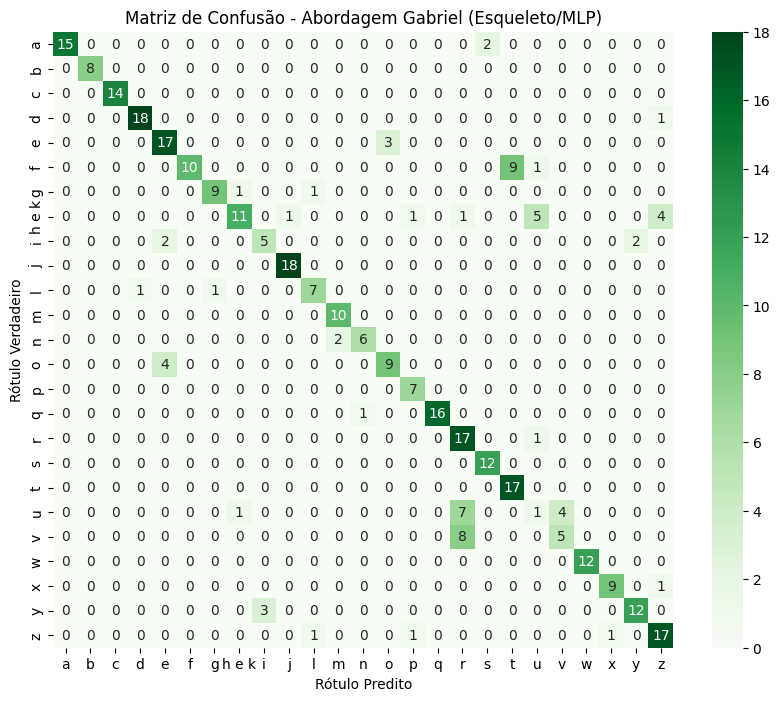

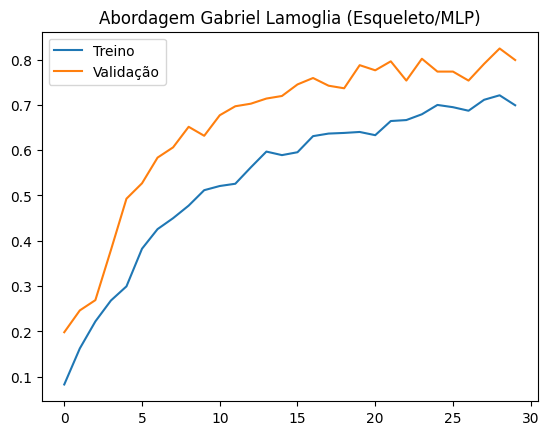

In [5]:
X, y_raw, num_classes, class_names = extract_landmarks(DATASET_PATH)

if len(X) == 0:
    print("Erro: Nenhuma mão detectada pelo MediaPipe. Verifique o dataset.")
    exit()

# 2. Pré-processamento
y_cat = to_categorical(y_raw, num_classes)
X_train, X_test, y_train_cat, y_test_cat = train_test_split(X, y_cat, test_size=0.2, random_state=42)

# Labels brutos para a matriz de confusão:
y_test_raw = np.argmax(y_test_cat, axis=1) 

# 3. Treino
model = build_mlp_model(42, num_classes) # 42 features (21 pontos x 2 eixos)
print(f"[Gabriel] Treinando MLP com {len(X)} amostras detectadas...")
history = model.fit(X_train, y_train_cat, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_test, y_test_cat))

# 4. Avaliação
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\n>>> Acurácia Final (Abordagem Gabriel/MediaPipe): {acc*100:.2f}%")

# --- NOVA SEÇÃO: ANÁLISE DETALHADA COM MATRIZ DE CONFUSÃO ---

# Fazer predições no conjunto de teste
y_pred_cat = model.predict(X_test)
y_pred_raw = np.argmax(y_pred_cat, axis=1) # Converte predições One-Hot de volta para índices

# Gerar e imprimir o Relatório de Classificação
print("\n--- Relatório de Classificação por Classe ---")
print(classification_report(y_test_raw, y_pred_raw, target_names=class_names))

# Gerar a Matriz de Confusão
cm = confusion_matrix(y_test_raw, y_pred_raw)

# Plotar a Matriz de Confusão 
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Abordagem Gabriel (Esqueleto/MLP)')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Predito')
plt.show()

# Plotar Acurácia de Treino/Validação
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Abordagem Gabriel Lamoglia (Esqueleto/MLP)')
plt.legend()
plt.show()

In [6]:
model.save('modelo_gabriel.keras')